In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!git clone https://github.com/rgeirhos/texture-vs-shape.git
%cd texture-vs-shape

Cloning into 'texture-vs-shape'...
remote: Enumerating objects: 2375, done.
remote: Counting objects: 100% (165/165), done.
remote: Compressing objects: 100% (136/136), done.
remote: Total 2375 (delta 31), reused 154 (delta 28), pack-reused 2210 (from 1)
Receiving objects: 100% (2375/2375), 148.67 MiB | 50.48 MiB/s, done.
Resolving deltas: 100% (257/257), done.
/kaggle/working/texture-vs-shape


In [2]:
!pip install torch torchvision matplotlib pandas -q

In [3]:
import sys
sys.path.insert(0, 'models')
from load_pretrained_models import load_model

# Load all 3 variants
model_A = load_model("resnet50_trained_on_SIN")                          # shape-biased
model_B = load_model("resnet50_trained_on_SIN_and_IN")                   # mixed
model_C = load_model("resnet50_trained_on_SIN_and_IN_then_finetuned_on_IN")  # finetuned

print("All models loaded successfully!")

Using the ResNet50 architecture.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/6f41d2e86fc60566f78de64ecff35cc61eb6436f/resnet50_train_60_epochs-c8e5653e.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_train_60_epochs-c8e5653e.pth.tar


100%|██████████| 195M/195M [00:11<00:00, 17.4MB/s] 


Using the ResNet50 architecture.
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/60b770e128fffcbd8562a3ab3546c1a735432d03/resnet50_train_45_epochs_combined_IN_SF-2a0d100e.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_train_45_epochs_combined_IN_SF-2a0d100e.pth.tar


100%|██████████| 195M/195M [00:11<00:00, 17.4MB/s] 


Using the ResNet50 architecture.
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/60b770e128fffcbd8562a3ab3546c1a735432d03/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar


100%|██████████| 195M/195M [00:13<00:00, 14.8MB/s] 


All models loaded successfully!


In [4]:
from torchvision import transforms
from PIL import Image
import torch, os

# Pick one cue-conflict image from the stimuli folder
img_dir = "stimuli/style-transfer-preprocessed-512"
categories = os.listdir(img_dir)
sample_img_path = os.path.join(img_dir, categories[0], os.listdir(os.path.join(img_dir, categories[0]))[0])

# Preprocess
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img = Image.open(sample_img_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0)

# Run through model_A
model_A.eval()
with torch.no_grad():
    output = model_A(input_tensor)

print(f"Image: {sample_img_path}")
print(f"Output shape: {output.shape}")  # Should be [1, 1000]
print("Baseline model ran successfully ✅")

Image: stimuli/style-transfer-preprocessed-512/chair/chair1-truck3.png
Output shape: torch.Size([1, 1000])
Baseline model ran successfully ✅


In [6]:
sys.path.insert(0, 'code')
import probabilities_to_decision

mapping = probabilities_to_decision.ImageNetProbabilitiesTo16ClassesMapping()
softmax_out = torch.nn.functional.softmax(output, dim=1).squeeze().cpu().numpy()
decision = mapping.probabilities_to_decision(softmax_out)
print(f"Model decision (16-class): {decision}")

Model decision (16-class): chair


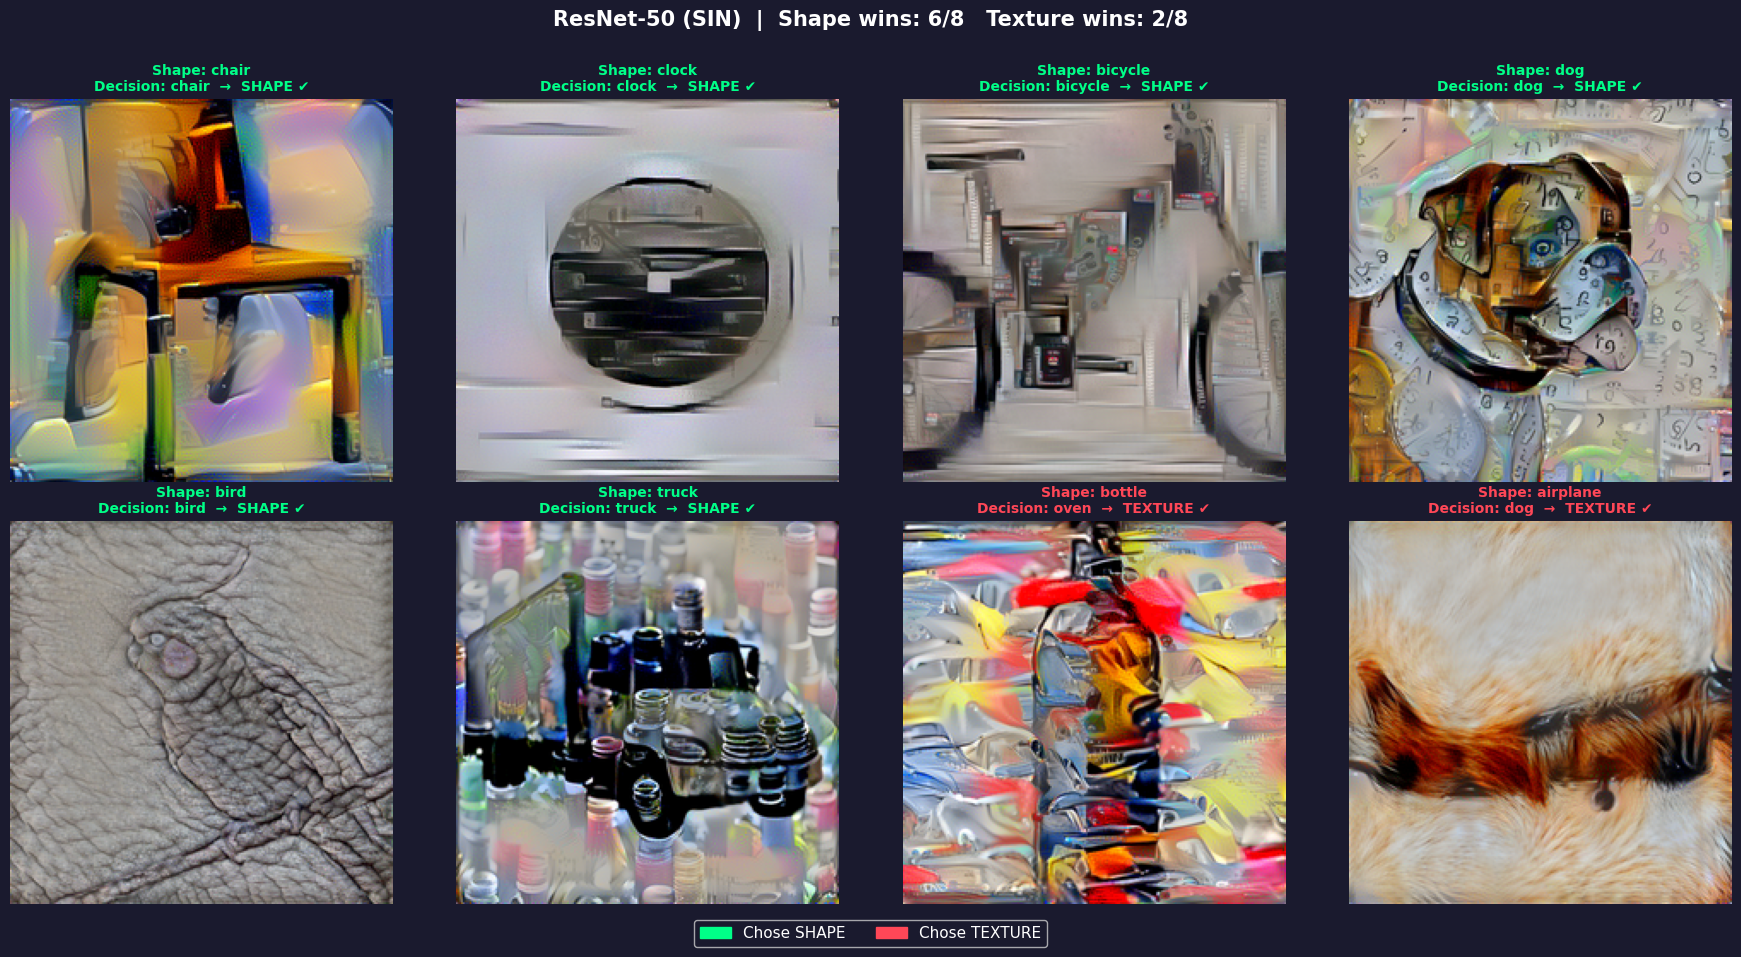

✅ Saved as baseline_visualization.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os
from PIL import Image
import torch

# ── collect results for a few images ──────────────────────────────────────
img_dir   = "stimuli/style-transfer-preprocessed-512"
results   = []
max_imgs  = 8   # show 8 images

for category in os.listdir(img_dir)[:max_imgs]:
    cat_path = os.path.join(img_dir, category)
    if not os.path.isdir(cat_path):
        continue
    img_file = os.listdir(cat_path)[0]
    img_path = os.path.join(cat_path, img_file)

    # parse shape & texture from filename  e.g. "cat_texture-elephant_shape-cat_..."
    parts      = img_file.replace('.png','').replace('.jpg','').split('_')
    shape_cat  = category                          # folder = shape category
    texture_cat = parts[1] if len(parts) > 1 else "unknown"   # best-effort parse

    img = Image.open(img_path).convert('RGB')
    inp = transform(img).unsqueeze(0).cuda()

    model_A.eval()
    with torch.no_grad():
        out = model_A(inp)

    soft = torch.nn.functional.softmax(out, dim=1).squeeze().cpu().numpy()
    decision = mapping.probabilities_to_decision(soft)

    results.append({
        "img"      : img,
        "shape"    : shape_cat,
        "texture"  : texture_cat,
        "decision" : decision,
        "correct"  : decision == shape_cat   # True = shape bias, False = texture bias
    })

# ── plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.patch.set_facecolor('#1a1a2e')
axes = axes.flatten()

shape_wins   = sum(1 for r in results if r["correct"])
texture_wins = len(results) - shape_wins

for ax, r in zip(axes, results):
    ax.imshow(r["img"])
    ax.axis('off')

    decided_shape   = r["decision"] == r["shape"]
    border_color    = "#00ff88" if decided_shape else "#ff4757"
    label_color     = "#00ff88" if decided_shape else "#ff4757"
    verdict         = "SHAPE ✔" if decided_shape else "TEXTURE ✔"

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(border_color)
        spine.set_linewidth(4)

    ax.set_title(
        f"Shape: {r['shape']}\nDecision: {r['decision']}  →  {verdict}",
        color=label_color, fontsize=10, fontweight='bold',
        pad=6
    )
    ax.set_facecolor('#1a1a2e')

# ── summary bar ───────────────────────────────────────────────────────────
fig.suptitle(
    f"ResNet-50 (SIN)  |  Shape wins: {shape_wins}/{len(results)}   Texture wins: {texture_wins}/{len(results)}",
    fontsize=15, fontweight='bold', color='white', y=1.01
)

# small legend
shape_patch   = mpatches.Patch(color='#00ff88', label='Chose SHAPE')
texture_patch = mpatches.Patch(color='#ff4757', label='Chose TEXTURE')
fig.legend(handles=[shape_patch, texture_patch],
           loc='lower center', ncol=2,
           facecolor='#1a1a2e', labelcolor='white',
           fontsize=11, framealpha=0.8, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig("baseline_visualization.png", dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("✅ Saved as baseline_visualization.png")